# Demosaicing vs. Direct Fit — Head-to-Head Comparison

Compares localisation precision (σ_xy) and colour precision (σ_colour) for three
fitting strategies on a Bayer-filtered camera:

| Strategy | Description |
|---|---|
| `STANDARD` | Direct fit to raw Bayer image with per-channel masks |
| `STANDARD_ITER` | Direct fit with iterative re-weighting |
| `STANDARD_DATA` | Direct fit with iterative re-weighting which ends with raw data weighting |

Ground truth positions are subtracted internally (`subtractx0y0=True`) so that
σ_xy = std(xc) is comparable across strategies without needing a shared ground-truth file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import types
import xarray as xr
from scipy.spatial.distance import cdist

import sys
import logging
sys.path.insert(0, "../../..")
logging.basicConfig(level=logging.INFO, format='%(name)s — %(levelname)s — %(message)s')

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions
from src.Multicolour_Simulation_Functions import FittingStrategy, CameraParameters, SimulationConfig
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()

print("Available fitting strategies:", [s.value for s in FittingStrategy])

Constants — INFO — Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/notebooks/figures/SI/../../../logs/Constants_20260506_175514.log


Available fitting strategies: ['standard', 'standard_iter', 'standard_data', 'demosaic', 'demosaic_fast', 'demosaic_ig', 'standard_ig']


## Camera calibration and optical setup

In [2]:
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain     = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset   = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe      = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])  # Bayer channel order: B, G, R

In [3]:
image_size = 14
masks = M_F.get_masks(size_x=image_size, size_y=image_size)

camera_parameters_dict = {
    "gain":     np.full((image_size, image_size), np.median(gain)),
    "offset":   np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise":np.full((image_size, image_size), np.median(readnoise)),
    "rqe":      np.full((image_size, image_size), np.median(rqe)),
    "masks":    masks,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
}

validated_camera = CameraParameters.validate_and_create(camera_parameters_dict)
print("Camera parameters validated.")

Camera parameters validated.


In [4]:
# Gaussian pre-smoothing applied before spot detection
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

# Optical path filters (same as Figure 1)
filters = [
    "semrock-di03-r405-488-561-635-t1-25x36",  # dichroic
    "semrock-nf03-405-488-561-635e",            # notch
]

## Simulation configuration

In [5]:
config = SimulationConfig(
    n_bootstrap=100000,
    background_photons=5.0,
    background_colour=[1, 1, 1],
    NA=1.49,
    pixel_size=69,
    cpu_fraction=0.9,
    save_raw_results=True,
    subtractx0y0=True,   # ground truth subtracted before saving — std(xc) = precision
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
)

# Dyes and photon range matching Figure 1
dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)

# Save folder
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260506_Standard_fitting_strategies"
os.makedirs(save_folder, exist_ok=True)
print(f"Results will be saved to: {save_folder}")

Results will be saved to: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260506_Standard_fitting_strategies


## Run simulations

Three strategies × three dyes.  
Each strategy uses a distinct `starting_flag` so files do not collide.  
Set `overwrite=False` to resume an interrupted run.

In [6]:
strategies = [
    (FittingStrategy.STANDARD, "standard_"),
    (FittingStrategy.STANDARD_ITER, "standard_iter_"),
    (FittingStrategy.STANDARD_DATA, "standard_data_"),
]

camera_params_dict = validated_camera.__dict__.copy()

for strategy, flag in strategies:
    for dye in dyes:
        print(f"Running {strategy.value} / {dye} ...")
        try:
            MSF.test_simulation_method(
                dye=dye,
                filters=filters,
                wavelength=wavelength,
                camera_parameters=camera_params_dict,
                save_folder=save_folder,
                n_photon_space=n_photon_space,
                smoothing_function=smoothing_function,
                strategy=strategy,
                starting_flag=flag,
                config=config,
                overwrite=True,
            )
            print(f"  Done: {strategy.value} / {dye}")
        except Exception as e:
            print(f"  FAILED {strategy.value} / {dye}: {e}")

print("All simulations complete.")


Running standard / ATTO 488 ...


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 246.662 min


  FAILED standard / ATTO 488: unsupported operand type(s) for /: 'PosixPath' and 'tuple'
Running standard / ATTO 565 ...


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 252.345 min


  FAILED standard / ATTO 565: unsupported operand type(s) for /: 'PosixPath' and 'tuple'
Running standard / ATTO 647N ...


...

  FAILED standard_data / ATTO 488: unsupported operand type(s) for /: 'PosixPath' and 'tuple'
Running standard_data / ATTO 565 ...


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 263.056 min


  FAILED standard_data / ATTO 565: unsupported operand type(s) for /: 'PosixPath' and 'tuple'
Running standard_data / ATTO 647N ...


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 272.131 min


  FAILED standard_data / ATTO 647N: unsupported operand type(s) for /: 'PosixPath' and 'tuple'
All simulations complete.


## Load results and compute precision metrics

Because `subtractx0y0=True`, the saved `xc` and `yc` columns are already
*(fitted − truth)*, so:

$$\sigma_{xy} = \sqrt{\frac{\sigma_x^2 + \sigma_y^2}{2}} \times 69\,\text{nm}$$

Colour precision is the standard deviation of the Euclidean distance from each
fitted $(A_B, A_G, A_R)$ point to the true colour vector.

In [7]:
strategy_labels = ["Direct fit", "Direct fit (ITER)", "Direct fit (DATA)"]
strategy_flags  = ["standard_", "standard_iter_", "standard_data_"]
parameters      = ["xy", "colour", "B", "G", "R", "chi_mean", "chi_median", "chi_std"]

all_files = os.listdir(save_folder)

Overall_XR = xr.DataArray(
    data=np.full([len(strategy_labels), len(dyes), len(n_photon_space), len(parameters)], np.nan),
    coords=[strategy_labels, dyes, n_photon_space, parameters],
    dims=["Strategy", "Dye", "Photon", "Metric"],
)

for i, (label, flag) in enumerate(zip(strategy_labels, strategy_flags)):
    # Use flag + "LM_method" as the discriminating prefix so that "standard_"
    # does not accidentally match "standard_iter_LM_method_..." files.
    prefix = flag + "LM_method"
    flag_files = [x for x in all_files if x.startswith(prefix)]
    for j, dye in enumerate(dyes):
        dyestr = dye.replace("/", "-")
        raw_files = [
            os.path.join(save_folder, x)
            for x in flag_files
            if dyestr in x and "rawresults" in x
        ]
        param_files = [
            os.path.join(save_folder, x)
            for x in flag_files
            if dyestr in x and "input_parameters" in x
        ]
        if not raw_files or not param_files:
            print(f"Missing files for {label} / {dye} — skipping.")
            continue

        true_bgr = pd.read_csv(param_files[0]).to_numpy()[0][-3:]
        true_bgr = true_bgr / np.sum(true_bgr)
        true_colour = np.expand_dims(true_bgr, 0)

        results_all = pd.read_hdf(raw_files[0])

        for k, photonval in enumerate(n_photon_space):
            results = results_all[results_all["photon_level"] == k]
            if len(results) == 0:
                continue

            filt = ~(
                (results["s_x"] < 0)
                | (results["s_y"] < 0)
 #               | (results["xc"].abs() > 14)
 #               | (results["yc"].abs() > 14)
 #               | (results["chi_sqr"] > 10)
            )

            xc = results["xc"].to_numpy()[filt]
            yc = results["yc"].to_numpy()[filt]
            chi_sqr = results["chi_sqr"].to_numpy()[filt]

            sigma_xy = np.sqrt((np.nanstd(xc)**2 + np.nanstd(yc)**2) / 2) * 69

            colour = np.vstack([
                results["A_B"].to_numpy()[filt],
                results["A_G"].to_numpy()[filt],
                results["A_R"].to_numpy()[filt],
            ]).T
            colour_dist = cdist(colour, true_colour).ravel()
            B_dist = np.sqrt(np.square(colour[:, 0] - true_colour[:, 0]))
            G_dist = np.sqrt(np.square(colour[:, 1] - true_colour[:, 1]))
            R_dist = np.sqrt(np.square(colour[:, 2] - true_colour[:, 2]))

            Overall_XR[i, j, k, 0] = sigma_xy
            Overall_XR[i, j, k, 1] = np.nanstd(colour_dist)
            Overall_XR[i, j, k, 2] = np.nanstd(B_dist)
            Overall_XR[i, j, k, 3] = np.nanstd(G_dist)
            Overall_XR[i, j, k, 4] = np.nanstd(R_dist)
            Overall_XR[i, j, k, 5] = np.nanmean(chi_sqr)
            Overall_XR[i, j, k, 6] = np.nanmedian(chi_sqr)
            Overall_XR[i, j, k, 7] = np.nanstd(chi_sqr)
            

print("Results loaded.")
Overall_XR.to_netcdf(os.path.join(save_folder, "Standard_Fit_Strategies.nc"))
print("Saved to Standard_Fit_Strategies.nc")

Results loaded.
Saved to Standard_Fit_Strategies.nc


In [8]:
# (Optional) reload without re-running the simulation
Overall_XR = xr.load_dataarray(os.path.join(save_folder, "Standard_Fit_Strategies.nc"))

## Plot — dye-averaged precision vs photon count

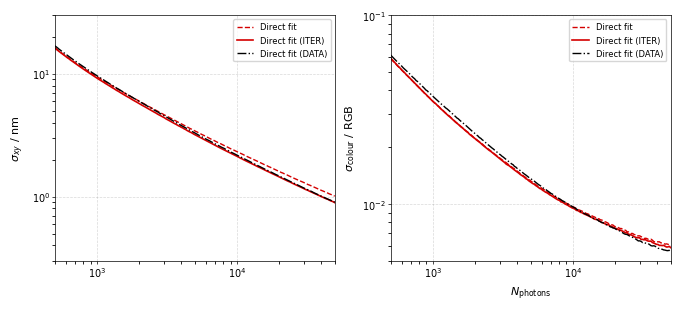

In [9]:
# Colours and line styles for each strategy
plot_styles = [

    {"color": "#d40000", "linestyle": "--", "linewidth": 1.0},
    {"color": "#d40000", "linestyle": "-",  "linewidth": 1.2},   # Direct fit
    {"color": "black",   "linestyle": "-.", "linewidth": 1.0},   # Demosaic (fast)
]

strategy_labels = ["Direct fit", "Direct fit (ITER)", "Direct fit (DATA)"]

fig, axs = plotter.two_column_plot(ncols=2, width_ratios=np.ones(2))

for i, (label, style) in enumerate(zip(strategy_labels, plot_styles)):
    mean_xy     = np.nanmean(Overall_XR[i, :, :, 0], axis=0)
    mean_colour = np.nanmean(Overall_XR[i, :, :, 1], axis=0)

    axs[0] = plotter.line_plot(
        axs[0], n_photon_space, mean_xy,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{xy}$ / nm",
        **style,
    )
    axs[1] = plotter.line_plot(
        axs[1], n_photon_space, mean_colour,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{\mathrm{colour}}$ / RGB",
        **style,
    )

for ax in axs:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([500, 50000])

axs[0].set_ylim([0.3, 30])
axs[0].set_xlabel("")
axs[1].set_ylim([5e-3, 0.1])
axs[0].legend(loc="best", fontsize=6)

fig_savefolder = "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/"
os.makedirs(fig_savefolder, exist_ok=True)
plt.savefig(os.path.join(fig_savefolder, "Demosaic_vs_DirectFit.svg"), dpi=600, format="svg")
plt.show()

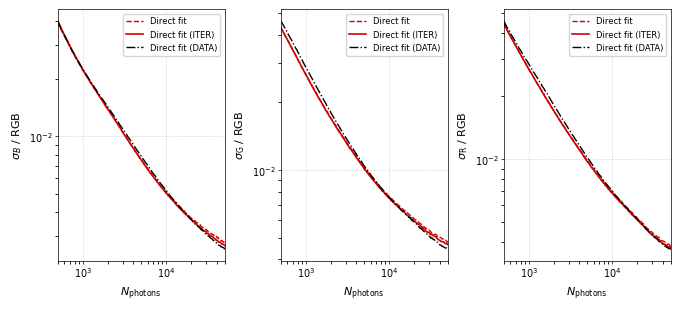

In [10]:
fig, axs = plotter.two_column_plot(ncols=3, width_ratios=np.ones(3))

for i, (label, style) in enumerate(zip(strategy_labels, plot_styles)):
    mean_B     = np.nanmean(Overall_XR[i, :, :, 2], axis=0)
    mean_G = np.nanmean(Overall_XR[i, :, :, 3], axis=0)
    mean_R = np.nanmean(Overall_XR[i, :, :, 4], axis=0)

    axs[0] = plotter.line_plot(
        axs[0], n_photon_space, mean_B,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{B}$ / RGB",
        **style,
    )
    axs[1] = plotter.line_plot(
        axs[1], n_photon_space, mean_G,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{\mathrm{G}}$ / RGB",
        **style,
    )
    
    axs[2] = plotter.line_plot(
        axs[2], n_photon_space, mean_R,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{\mathrm{R}}$ / RGB",
        **style,
    )

for ax in axs:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([500, 50000])
    #ax.set_ylim([5e-3, 0.1])

axs[0].legend(loc="best", fontsize=6)

fig_savefolder = "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/"
os.makedirs(fig_savefolder, exist_ok=True)
plt.savefig(os.path.join(fig_savefolder, "Demosaic_vs_DirectFit_RGB.svg"), dpi=600, format="svg")
plt.show()

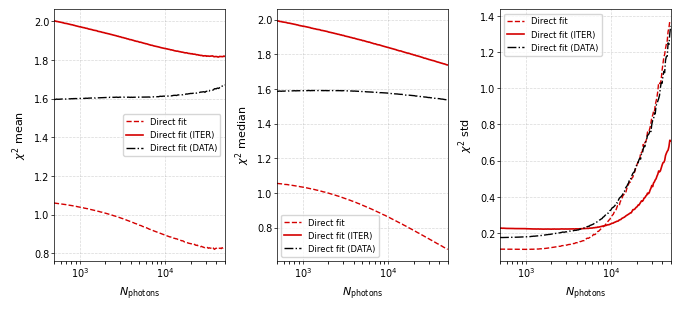

In [11]:
fig, axs = plotter.two_column_plot(ncols=3, width_ratios=np.ones(3))

for i, (label, style) in enumerate(zip(strategy_labels, plot_styles)):
    chi_sqr_mean     = np.nanmean(Overall_XR[i, :, :, 5], axis=0)
    chi_sqr_median = np.nanmean(Overall_XR[i, :, :, 6], axis=0)
    chi_sqr_std = np.nanmean(Overall_XR[i, :, :, 7], axis=0)

    axs[0] = plotter.line_plot(
        axs[0], n_photon_space, chi_sqr_mean,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\chi^2$ mean",
        **style,
    )
    axs[1] = plotter.line_plot(
        axs[1], n_photon_space, chi_sqr_median,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\chi^2$ median",
        **style,
    )
    
    axs[2] = plotter.line_plot(
        axs[2], n_photon_space, chi_sqr_std,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\chi^2$ std",
        **style,
    )

for ax in axs:
    ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlim([500, 50000])
    #ax.set_ylim([5e-3, 0.1])

axs[0].legend(loc="best", fontsize=6)

fig_savefolder = "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/"
os.makedirs(fig_savefolder, exist_ok=True)
plt.savefig(os.path.join(fig_savefolder, "Demosaic_vs_DirectFit_Chi.svg"), dpi=600, format="svg")
plt.show()

## Per-dye breakdown

Show each dye separately to check whether the ranking is consistent.

In [ ]:
fig, axs = plt.subplots(
    2, len(dyes),
    figsize=(3.2535433 * len(dyes) / 2, 3.1909449),
    sharex=True,
)

for j, dye in enumerate(dyes):
    for i, (label, style) in enumerate(zip(strategy_labels, plot_styles)):
        axs[0, j].plot(
            n_photon_space, Overall_XR[i, j, :, 0],
            label=label if j == 0 else None,
            **style,
        )
        axs[1, j].plot(
            n_photon_space, Overall_XR[i, j, :, 1],
            **style,
        )
    axs[0, j].set_title(dye, fontsize=7)

for row in range(2):
    for col in range(len(dyes)):
        axs[row, col].set_xscale("log")
        axs[row, col].set_yscale("log")
        axs[row, col].set_xlim([500, 50000])

for col in range(len(dyes)):
    axs[0, col].set_ylim([0.3, 30])
    axs[1, col].set_ylim([5e-3, 0.3])
    axs[1, col].set_xlabel(r"$N_{\mathrm{photons}}$", fontsize=7)

axs[0, 0].set_ylabel(r"$\sigma_{xy}$ / nm", fontsize=7)
axs[1, 0].set_ylabel(r"$\sigma_{\mathrm{colour}}$ / RGB", fontsize=7)
axs[0, 0].legend(loc="best", fontsize=5)

plt.tight_layout()
plt.savefig(os.path.join(fig_savefolder, "Demosaic_vs_DirectFit_PerDye.svg"), dpi=600, format="svg")
plt.show()

## Ratio plot — demosaic relative to direct fit

Values > 1 mean the demosaic strategy is worse (larger std); values < 1 mean it is better.

In [ ]:
fig, axs = plotter.one_column_plot(npanels=2, height=3.1909449, ratios=[1, 1], width=3.2535433)

ref_xy     = np.nanmean(Overall_XR[0, :, :, 0], axis=0)  # STANDARD
ref_colour = np.nanmean(Overall_XR[0, :, :, 1], axis=0)

for i, (label, style) in enumerate(zip(strategy_labels[1:], plot_styles[1:]), start=1):
    mean_xy     = np.nanmean(Overall_XR[i, :, :, 0], axis=0)
    mean_colour = np.nanmean(Overall_XR[i, :, :, 1], axis=0)

    axs[0] = plotter.line_plot(
        axs[0], n_photon_space, mean_xy / ref_xy,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{xy}$ / $\sigma_{xy}^{\mathrm{direct}}$",
        **style,
    )
    axs[1] = plotter.line_plot(
        axs[1], n_photon_space, mean_colour / ref_colour,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{\mathrm{colour}}$ / $\sigma_{\mathrm{colour}}^{\mathrm{direct}}$",
        **style,
    )

for ax in axs:
    ax.set_xscale("log")
    ax.set_xlim([500, 50000])
    ax.axhline(1.0, color="#d40000", lw=0.8, ls="-", label="Direct fit (reference)")

axs[0].set_xlabel("")
axs[0].legend(loc="best", fontsize=6)

plt.savefig(os.path.join(fig_savefolder, "Demosaic_vs_DirectFit_Ratio.svg"), dpi=600, format="svg")
plt.show()